In [48]:
# ==============================================================================
# MASTER NOTEBOOK: AIRLINE ROUTE CLUSTERING ANALYSIS
# ==============================================================================
# Author: Guilherme F Dellatin (Expert Data Scientist Persona)
# Context: Consolidates best practices from previous iterations (v1, v2, v3)
# Objective: Segment airline routes to identify operational patterns using K-Means.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from modules.kmeans_k_evaluator import KMeansKEvaluator
import warnings

# Configuration for cleaner output
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set_context("notebook", font_scale=1.1)

In [49]:
# ==============================================================================
# 1. DATA LOADING & PREPROCESSING
# ==============================================================================
print("Loading dataset...")
cols = ['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT','DEPARTURE_DELAY', 'DISTANCE','CANCELLED', 'DIVERTED']
# Assuming standard file path (adjust as necessary)
df = pd.read_csv('data/flights.csv', usecols=cols, low_memory=False)
#df = pd.read_csv('flights.csv', usecols=['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
#                                         'DEPARTURE_DELAY', 'DISTANCE',
#                                         'CANCELLED', 'DIVERTED'])

print(f"Original shape: {df.shape}")

# 1.1 Clean Data
# Remove canceled or diverted flights as they distort delay metrics
df_clean = df[(df['CANCELLED'] == 0) & (df['DIVERTED'] == 0)]
df_clean = df_clean.dropna(subset=['DEPARTURE_DELAY'])

Loading dataset...
Original shape: (5819079, 6)


In [50]:
# ==============================================================================
# 2. FEATURE ENGINEERING (Route Aggregation)
# ==============================================================================
print("Aggregating data by route...")

# Group by unique route (Origin -> Destination)
route_stats = df_clean.groupby(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']).agg({
    'DEPARTURE_DELAY': 'mean',  # Avg delay represents operational efficiency
    'DISTANCE': 'mean',         # Avg distance represents route type (Short/Long haul)
    'ORIGIN_AIRPORT': 'count'   # Count represents route frequency/demand
}).rename(columns={'ORIGIN_AIRPORT': 'flight_count',
                   'DEPARTURE_DELAY': 'avg_delay',
                   'DISTANCE': 'avg_distance'})

# Reset index to make Origin/Dest columns available
route_stats = route_stats.reset_index()

# 2.1 Statistical Filtering (Best Practice from NB-2)
# Filter out routes with very few flights (sparse data noise)
# Keeping routes with > 50 flights/year ensures statistical significance
MIN_FLIGHTS = 50
df_routes = route_stats[route_stats['flight_count'] > MIN_FLIGHTS].copy()

print(f"Routes analyzed (after filtering < {MIN_FLIGHTS} flights): {len(df_routes)}")

# 2.2 Advanced Transformation (Expert Addition)
# Flight counts often follow a power law. Log transform helps K-Means (which assumes spherical clusters).
df_routes['log_frequency'] = np.log1p(df_routes['flight_count'])

Aggregating data by route...
Routes analyzed (after filtering < 50 flights): 7012


In [51]:
# ==============================================================================
# 3. SCALING & OPTIMAL K SEARCH (Elbow + Silhouette + Stability)
# ==============================================================================

# Select features for clustering
features = ['avg_delay', 'avg_distance', 'log_frequency']
X = df_routes[features]

# Standardize features (Mean=0, Std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------------------------------------------------
# 3.1 Evaluate K candidates: Inertia (Elbow) + Silhouette + Stability (ARI)
# ----------------------------------------------------------------------
print("Determining optimal number of clusters (k)...")

evaluator = KMeansKEvaluator(
    k_min=2,
    k_max=10,
    base_seed=42,
    n_init=10,
    stability_seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 42],
    silhouette_sample_size=10000
)

df_k = evaluator.evaluate(X_scaled)

# Choose OPTIMAL_K automatically:
# 1) max silhouette, 2) max stability (ARI), 3) prefer smaller k
df_rank = df_k.sort_values(
    by=["silhouette", "mean_ari_vs_base", "k"],
    ascending=[False, False, True]
).reset_index(drop=True)

OPTIMAL_K = int(df_rank.loc[0, "k"])
best_sil = float(df_rank.loc[0, "silhouette"])

print("\n" + "-"*80)
print("K-SELECTION TABLE (higher silhouette is better; lower inertia is better; higher ARI is more stable)")
print("-"*80)
pd.set_option('display.float_format', '{:.4f}'.format)
print(df_k.to_string(index=False))
print("-"*80)
print(f"Selected OPTIMAL_K = {OPTIMAL_K} (silhouette={best_sil:.4f})")
print("-"*80)

Determining optimal number of clusters (k)...

--------------------------------------------------------------------------------
K-SELECTION TABLE (higher silhouette is better; lower inertia is better; higher ARI is more stable)
--------------------------------------------------------------------------------
 k    inertia  silhouette  mean_ari_vs_base  silhouette_std_across_seeds  inertia_reduction_%
 2 14734.7041      0.2981            0.9979                       0.0000                  NaN
 3 10897.4647      0.3316            0.9973                       0.0002              26.0422
 4  8854.0573      0.3360            0.9982                       0.0002              18.7512
 5  7916.8733      0.2610            0.9879                       0.0004              10.5848
 6  7099.7526      0.2560            0.9795                       0.0006              10.3213
 7  6401.9211      0.2590            0.9928                       0.0004               9.8290
 8  5882.7542      0.2580        

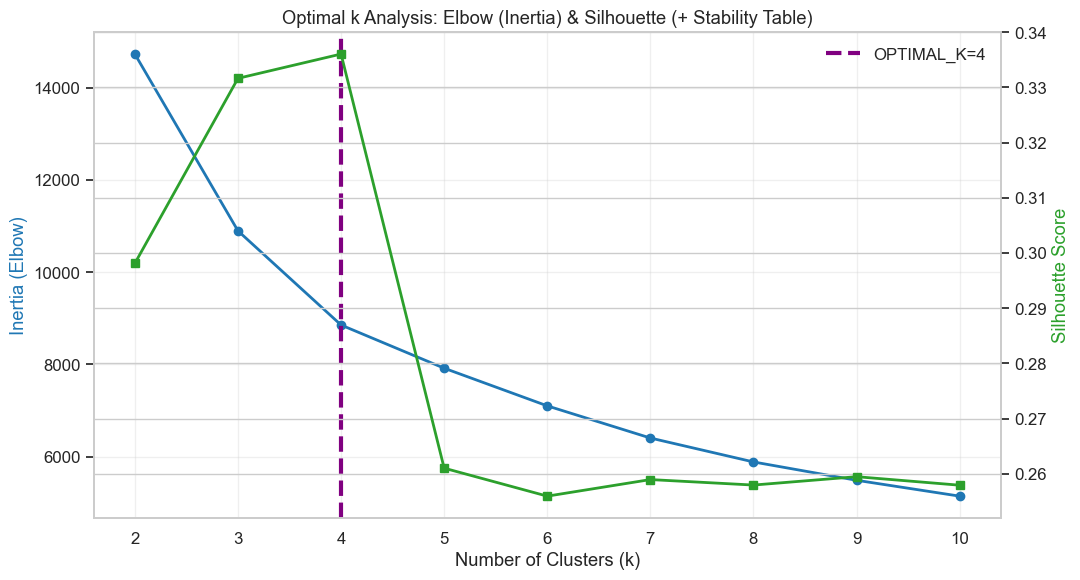

In [52]:
# ----------------------------------------------------------------------
# 3.2 Plots: Elbow (inertia) + Silhouette (with OPTIMAL_K marker)
# ----------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(11, 6))
color_blue = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Elbow)', color=color_blue)
ax1.plot(df_k["k"], df_k["inertia"], marker='o', color=color_blue, linewidth=2)
ax1.axvline(x=OPTIMAL_K, linestyle='--', color='purple', linewidth=3, label=f'OPTIMAL_K={OPTIMAL_K}')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color_green = 'tab:green'
ax2.set_ylabel('Silhouette Score', color=color_green)
ax2.plot(df_k["k"], df_k["silhouette"], marker='s', color=color_green, linewidth=2)

plt.title('Optimal k Analysis: Elbow (Inertia) & Silhouette (+ Stability Table)')
ax1.legend(loc='best')
plt.tight_layout()
plt.show()

In [53]:
# ==============================================================================
# 4. CLUSTERING MODEL (K-Means)
# ==============================================================================
# OPTIMAL_K is selected automatically in Section 3 (Silhouette + Stability).
print(f"Applying K-Means with OPTIMAL_K={OPTIMAL_K}...")
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_routes['cluster'] = kmeans_final.fit_predict(X_scaled)


Applying K-Means with OPTIMAL_K=4...


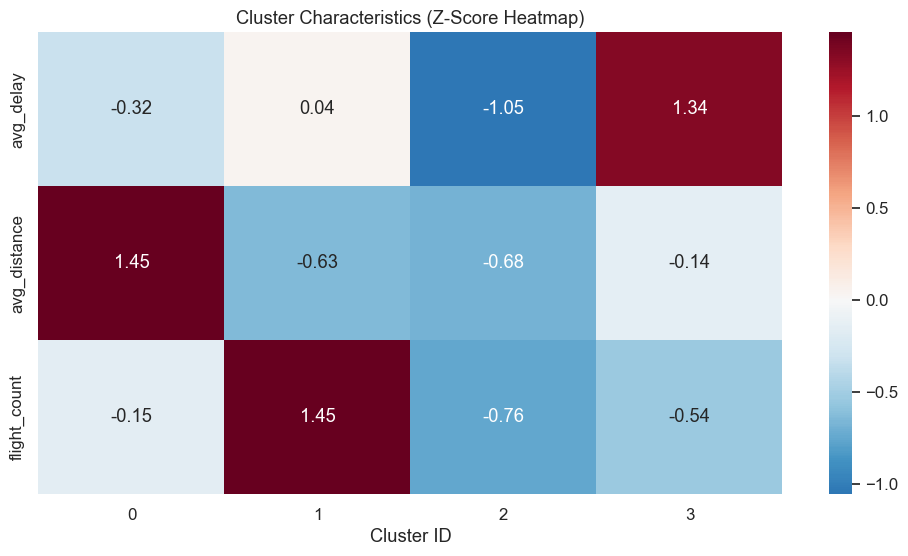

In [54]:
# ==============================================================================
# 5. VISUALIZATION & INTERPRETATION
# ==============================================================================

# 5.1 Cluster Profiling Plot
# Calculate mean values for original features per cluster
cluster_profile = df_routes.groupby('cluster')[['avg_delay', 'avg_distance', 'flight_count']].mean()

# Plot
plt.figure(figsize=(12, 6))
# Normalize for visualization comparison
cluster_profile_norm = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()
sns.heatmap(cluster_profile_norm.T, cmap='RdBu_r', center=0, annot=True, fmt='.2f')
plt.title('Cluster Characteristics (Z-Score Heatmap)')
plt.xlabel('Cluster ID')
plt.show()

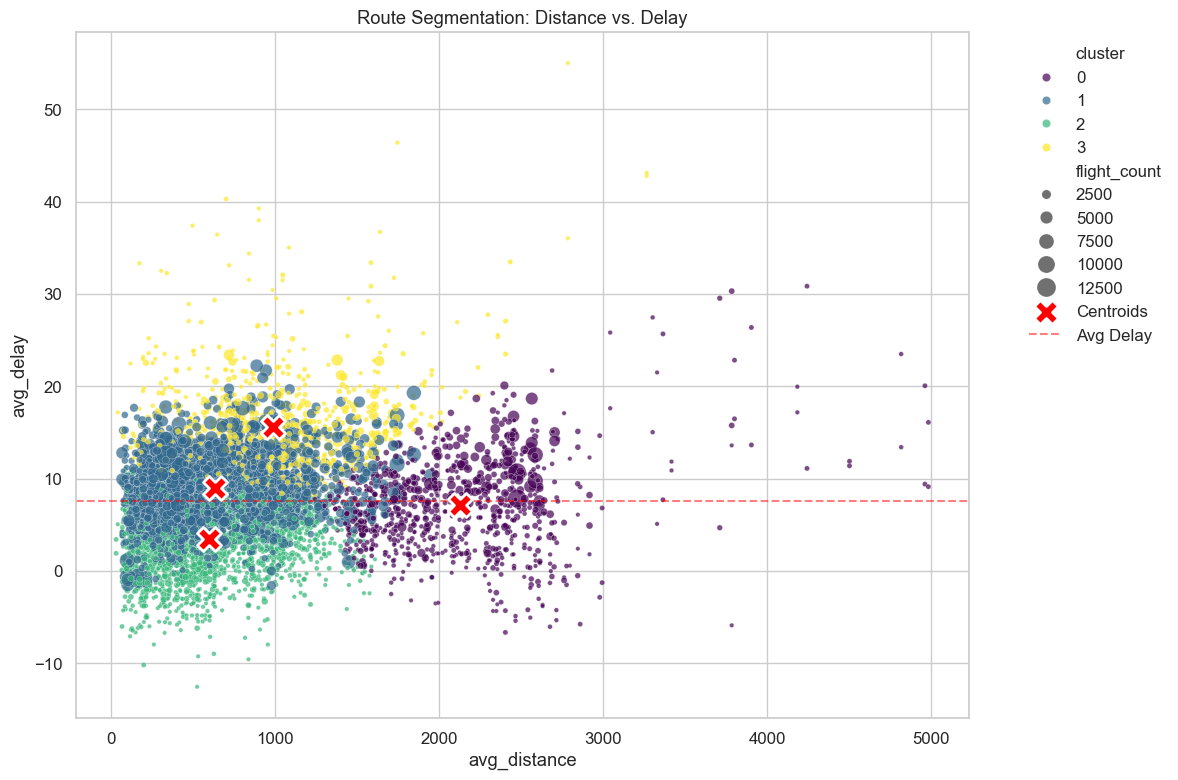

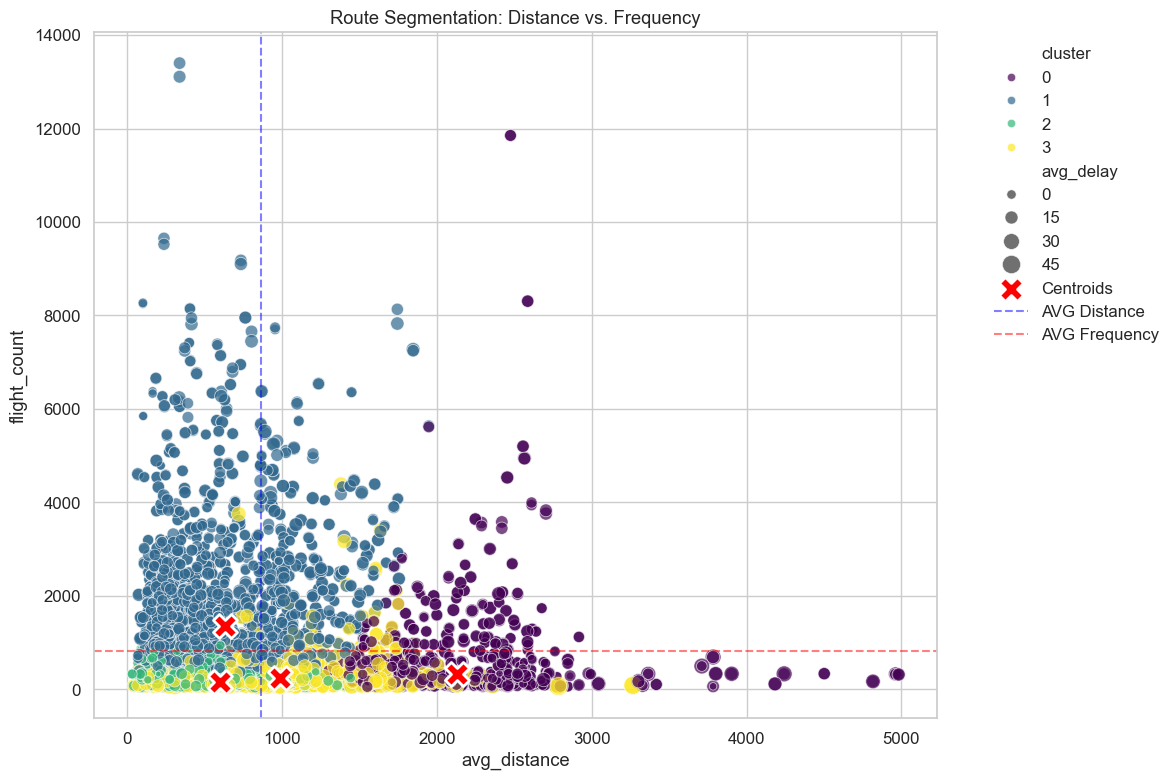

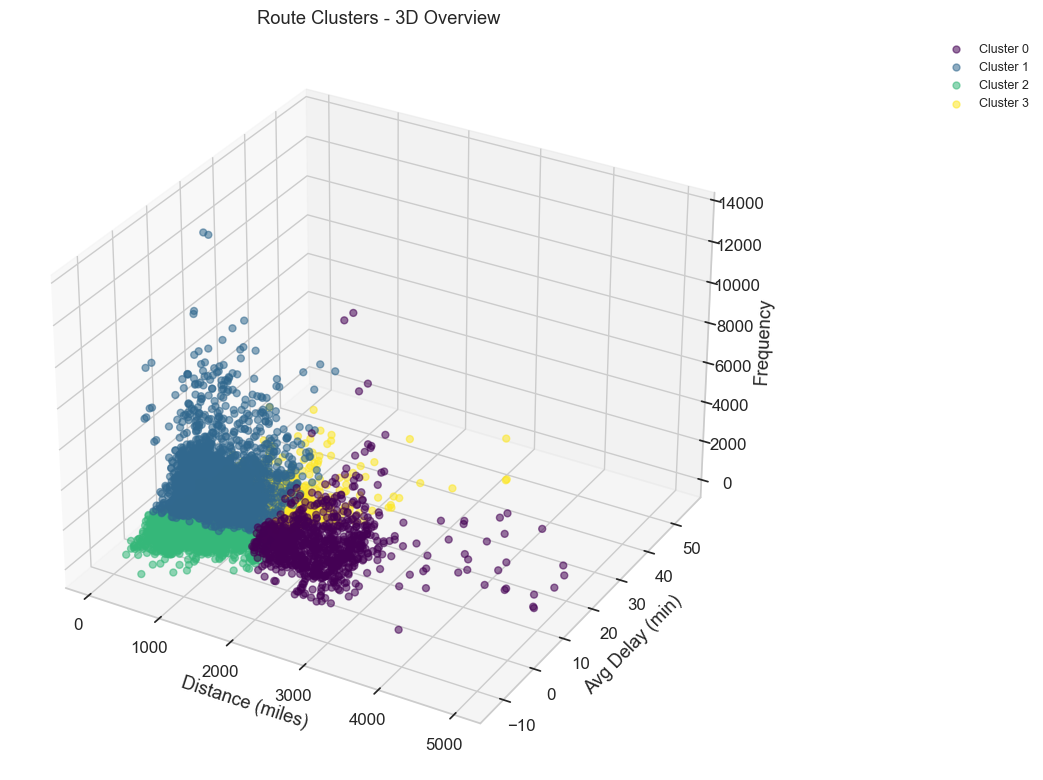

In [55]:
# ----------------------------------------------------------------------
# 5.2 Scatter Plot: Distance vs Delay (Size = Frequency) with Centroids
# ----------------------------------------------------------------------
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_routes, x='avg_distance', y='avg_delay',
                hue='cluster', palette='viridis', size='flight_count',
                sizes=(10, 200), alpha=0.7)

# It retrieves centroids and converts them to the original scale.
# features = ['avg_delay', 'avg_distance', 'log_frequency']
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

# Plots the centroids (indices: 0=avg_delay, 1=avg_distance, 2=log_frequency)
plt.scatter(
    centroids_original[:, 1],
    centroids_original[:, 0],
    c='red',
    marker='X',
    s=300,
    edgecolors='white',
    linewidths=2,
    label='Centroids',
    zorder=10
)

plt.title('Route Segmentation: Distance vs. Delay')
plt.axhline(y=df_routes['avg_delay'].mean(), color='red', linestyle='--', alpha=0.5, label='Avg Delay')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_routes,
    x="avg_distance",
    y="flight_count",
    hue="cluster",
    palette="viridis",
    size="avg_delay",
    sizes=(10, 200),
    alpha=0.7
)

# Retrieve centroids and convert them to the original scale
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

# Centroid indices: 0=avg_delay, 1=avg_distance, 2=log_frequency
centroid_distance = centroids_original[:, 1]
centroid_frequency = np.exp(centroids_original[:, 2])  # log -> original (approx)

# Plot centroids on (distance, frequency)
plt.scatter(
    centroid_distance,
    centroid_frequency,
    c="red",
    marker="X",
    s=300,
    edgecolors="white",
    linewidths=2,
    label="Centroids",
    zorder=10
)

plt.title("Route Segmentation: Distance vs. Frequency")
plt.axvline(x=df_routes['avg_distance'].mean(), color='blue', linestyle='--', alpha=0.5, label='AVG Distance')
plt.axhline(y=df_routes['flight_count'].mean(), color='red', linestyle='--', alpha=0.5, label='AVG Frequency')
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 3D Scatter - Distance x Delay x Frequency + Centroids (with legend like 2D)
# ----------------------------------------------------------------------
# Notes:
# - 3D plots are harder to read, but good for a quick holistic sanity check.
# - Color encodes cluster; points include all routes;
# ----------------------------------------------------------------------

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Build a stable color map for clusters
clusters = sorted(df_routes["cluster"].unique())
cmap = plt.cm.get_cmap("viridis", len(clusters))

# Plot points per cluster so we can get a proper legend
for i, cluster_id in enumerate(clusters):
    mask = df_routes["cluster"] == cluster_id
    ax.scatter(
        df_routes.loc[mask, "avg_distance"],
        df_routes.loc[mask, "avg_delay"],
        df_routes.loc[mask, "flight_count"],
        color=cmap(i),
        alpha=0.55,
        s=25,
        label=f"Cluster {cluster_id}"
    )

# Plot centroids
"""ax.scatter(
    centroid_distance,
    centroids_original[:, 0],  # centroid_delay
    centroid_frequency,
    c="red",
    marker="X",
    s=250,
    edgecolors="white",
    linewidths=2,
    label="Centroids",
    depthshade=False
)"""

ax.set_xlabel("Distance (miles)")
ax.set_ylabel("Avg Delay (min)")
ax.set_zlabel("Frequency")
ax.set_title("Route Clusters - 3D Overview")

# Legend outside, similar to 2D plots
ax.legend(bbox_to_anchor=(1.25, 1), loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()


In [56]:
# ==============================================================================
# 6. BUSINESS REPORTING (The "Hybrid Strategy" Summary)
# ==============================================================================
print("\n" + "="*80)
print("EXECUTIVE SUMMARY OF FLIGHT ROUTE CLUSTERS")
print("="*80)

# Generate detailed text report
for cluster_id in sorted(df_routes['cluster'].unique()):
    c_data = df_routes[df_routes['cluster'] == cluster_id]

    # Representative Routes (Top 3 by volume)
    top_routes = c_data.nlargest(3, 'flight_count')
    examples = [f"{row['ORIGIN_AIRPORT']}->{row['DESTINATION_AIRPORT']}" for _, row in top_routes.iterrows()]

    print(f"\n CLUSTER {cluster_id}: {len(c_data):,} routes")
    print(f"   • Avg Delay:     {c_data['avg_delay'].mean():5.1f} min")
    print(f"   • Avg Distance:  {c_data['avg_distance'].mean():5.0f} miles")
    print(f"   • Avg Frequency: {c_data['flight_count'].mean():5.0f} flights/year")
    print(f"   • Key Examples:  {', '.join(examples)}")

    # Automated Interpretation Logic
    if c_data['avg_distance'].mean() > 2000:
        label = "LONG HAUL / TRANSCONTINENTAL"
    elif c_data['flight_count'].mean() > 3000:
        label = "HIGH FREQUENCY / SHUTTLE ROUTES"
    elif c_data['avg_delay'].mean() > 15:
        label = "PROBLEM ROUTES (HIGH DELAY)"
    else:
        label = "REGIONAL / LOW DENSITY"
    print(f" INTERPRETATION: {label}")

print("\n" + "="*80)

# Export results
df_routes.to_csv('data/clustered_routes.csv', index=False)
print("Results exported to 'clustered_routes.csv'")


EXECUTIVE SUMMARY OF FLIGHT ROUTE CLUSTERS

 CLUSTER 0: 915 routes
   • Avg Delay:       7.1 min
   • Avg Distance:   2130 miles
   • Avg Frequency:   615 flights/year
   • Key Examples:  JFK->LAX, LAX->JFK, SFO->JFK
 INTERPRETATION: LONG HAUL / TRANSCONTINENTAL

 CLUSTER 1: 2,427 routes
   • Avg Delay:       9.0 min
   • Avg Distance:    632 miles
   • Avg Frequency:  1763 flights/year
   • Key Examples:  SFO->LAX, LAX->SFO, LAS->LAX
 INTERPRETATION: REGIONAL / LOW DENSITY

 CLUSTER 2: 2,651 routes
   • Avg Delay:       3.4 min
   • Avg Distance:    597 miles
   • Avg Frequency:   185 flights/year
   • Key Examples:  IDA->SLC, BZN->SLC, BUR->SEA
 INTERPRETATION: REGIONAL / LOW DENSITY

 CLUSTER 3: 1,019 routes
   • Avg Delay:      15.5 min
   • Avg Distance:    987 miles
   • Avg Frequency:   337 flights/year
   • Key Examples:  IAH->LAX, ORD->EWR, IAH->SFO
 INTERPRETATION: PROBLEM ROUTES (HIGH DELAY)

Results exported to 'clustered_routes.csv'
